In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.integrate import solve_ivp

import tinyDA as tda

# forward model evaluations

import pyvista as pv
import ufl
from dolfinx import fem, mesh, plot, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI


from ufl import dx, grad, inner

from helpers import interpolate_nonmatching, plot_function
import pyvista

import pickle
import sklearn as sk
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel

import arviz as az
import corner
import math

In [4]:
#!pip install tinyda

def extract_parameters(list):
    output = []
    for element in list:
        output.append(element.parameters.tolist())

    points = output

    diffs = np.diff(points, axis=0)
    distances = np.linalg.norm(diffs, axis=1)

    avg_distance = distances.mean()
    zero_count = np.sum(distances == 0)

    print("Average distance:", avg_distance)
    print("Zero-distance pairs:", zero_count)

    return(np.array(output))

## Forward Model Setup

In [7]:
class LinearElasticity:
    def __init__(self, solve_mesh: mesh, observation_mesh: mesh) -> None:
        self._observation_mesh = observation_mesh
        self._mesh = solve_mesh
        self._V = fem.functionspace(self._mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))
        self._V_observation = fem.functionspace(self._observation_mesh, ("Lagrange", 1, (self._mesh.geometry.dim, )))

        # boundary conditions
        facets_left = mesh.locate_entities_boundary(
            self._mesh,
            dim=(self._mesh.topology.dim - 1),
            marker=lambda x: np.isclose(x[0], 0.0),
        )
        dofs_left = fem.locate_dofs_topological(
            V=self._V, entity_dim=self._mesh.topology.dim - 1, entities=facets_left
        )
        bc_left = fem.dirichletbc(
            value=default_scalar_type((0, 0)), dofs=dofs_left, V=self._V
        )

        # coefficient setup
        u = ufl.TrialFunction(self._V)
        v = ufl.TestFunction(self._V)
        f = fem.Constant(self._mesh, default_scalar_type((0, -0.1)))
        x = ufl.SpatialCoordinate(self._mesh)

        # ── Inferred parameters: E1, E2 (Young's moduli left/right half) ──
        nu = 0.3  # fixed Poisson's ratio
        self._E1 = fem.Constant(self._mesh, default_scalar_type(20.0))
        self._E2 = fem.Constant(self._mesh, default_scalar_type(10.0))

        # Lamé parameters derived from E and nu
        # lambda = E*nu / ((1+nu)*(1-2*nu)),  mu = E / (2*(1+nu))
        def lam(E):
            return E * nu / ((1 + nu) * (1 - 2 * nu))

        def mu(E):
            return E / (2 * (1 + nu))

        def E_field(x):
            bottom = np.min(self._mesh.geometry.x[:, 1])
            top    = np.max(self._mesh.geometry.x[:, 1])
            height = top - bottom
            return ufl.conditional(x[1] <= bottom + height / 2, self._E1, self._E2)

        def epsilon(u):
            return 0.5 * (ufl.grad(u) + ufl.grad(u).T)

        def sigma(u):
            E = E_field(x)
            return lam(E) * ufl.nabla_div(u) * ufl.Identity(len(u)) + mu(E) * epsilon(u)

        # weak formulation
        a = inner(sigma(u), epsilon(v)) * dx
        L = inner(f, v) * dx

        self._problem = LinearProblem(
            a,
            L,
            bcs=[bc_left],
            petsc_options={"ksp_type": "cg", "pc_type": "gamg"},
            petsc_options_prefix="lp",
        )

        # performance optimization
        self._cells_V_to = np.arange(
            self._V_observation.mesh.topology.index_map(
                self._V_observation.mesh.topology.dim
            ).size_local,
            dtype=np.int32,
        )
        self._interpolation_data = fem.create_interpolation_data(
            self._V_observation, self._V, self._cells_V_to
        )

    def _evaluate(self, state: np.ndarray) -> np.ndarray:
        # state = [log(E1), log(E2)]
        self._E1.value = state[0]
        self._E2.value = state[1]
        return self._problem.solve()

    def __call__(self, state: np.ndarray) -> np.ndarray:
        """Evaluation of the observation operator"""
        pde_sol = self._evaluate(state)
        observed = interpolate_nonmatching(
            self._V_observation,
            self._V,
            pde_sol,
            self._interpolation_data,
            self._cells_V_to,
        )
        return observed.x.array, 0  # placeholder for qoi

    @property
    def gdim(self):
        return self._mesh.geometry.dim

    @property
    def ndofs(self):
        return self._V.dofmap.index_map.size_global

    def plot(self, solution):
        """Plot forward model output, indicate regions of different E."""

        def E_numpy(x):
            bottom = np.min(self._mesh.geometry.x[:, 1])
            top    = np.max(self._mesh.geometry.x[:, 1])
            height = top - bottom
            return np.where(x[:, 1] <= bottom + height / 2, self._E1.value, self._E2.value)

        p = pyvista.Plotter()
        topology, cell_types, geometry = plot.vtk_mesh(self._V_observation)
        grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

        u_2d = solution.reshape((geometry.shape[0], 2))
        u_3d = np.column_stack([u_2d, np.zeros(u_2d.shape[0])])

        E_vals = E_numpy(geometry)

        grid["u"] = u_3d
        grid["E"] = E_vals
        warped = grid.warp_by_vector("u", factor=1.5)

        boundary = grid.extract_feature_edges(
            boundary_edges=True, feature_edges=False,
            manifold_edges=False, non_manifold_edges=False,
        )
        p.add_mesh(boundary, color="k", line_width=2)
        p.add_mesh(warped, scalars="E", cmap="viridis", show_edges=True)
        p.add_scalar_bar(title="E (Young's modulus)")
        p.show_axes()
        if not pyvista.OFF_SCREEN:
            p.show()
        else:
            p.screenshot("deflection.png")

In [8]:
# UNIFORM REFINEMENT

_msh = mesh.create_rectangle(MPI.COMM_WORLD,
    [np.array([0, 0]), np.array([3, 1])],  # x goes from 0 → 3 instead of 0 → 1
    [50, 10])
_msh.topology.create_entities(1)

_msh2 = mesh.refine(_msh)[0]
_msh2.topology.create_entities(1)

_msh3 = mesh.refine(_msh2)[0]
_msh3.topology.create_entities(1)
_msh4 = mesh.refine(_msh3)[0]
_msh4.topology.create_entities(1)
_msh5 = mesh.refine(_msh4)[0]
_msh5.topology.create_entities(1)
_msh_data = mesh.refine(_msh5)[0]

_obs_msh = mesh.create_rectangle(
    MPI.COMM_WORLD, 
    [[0.05, 0.05], [2.95, 0.95]],  # slightly inset from [0,0] → [3,1]
    [6, 2]
)

In [9]:
# MODEL HIERARCHY

model1 = LinearElasticity(_msh, _obs_msh)
model2 = LinearElasticity(_msh2, _obs_msh)
model3 = LinearElasticity(_msh3, _obs_msh)
model_data = LinearElasticity(_msh_data, _obs_msh)

## Inverse Problem Setup

In [10]:
np.random.seed(678)

In [ ]:
# set true parameter(s)
# reevaluate noise 

E1 = 80
E2 = 40

true_parameters = np.array([E1, E2]) # no log

x_true = model_data(true_parameters)[0] # true displacement
x_true.shape

# generate data

sigma = 0.005

noise = np.random.normal(scale=sigma, size=(x_true.shape[0]))
data = x_true+noise

In [12]:
model2.plot(data)

Widget(value='<iframe src="http://localhost:57129/index.html?ui=P_0x174b98810_0&reconnect=auto" class="pyvista…

In [13]:
#uniform_prior = stats.uniform(loc=np.log(0.5), scale=bnp.log(1.5)-np.log(0.5))
#uniform_prior = stats.uniform(loc=0, scale=2)

prior_E1 = stats.uniform(loc=50, scale=50)
prior_E2 = stats.uniform(loc=0.1, scale=50)

my_prior = tda.CompositePrior([prior_E1, prior_E2])

/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.11/site-packages/tinyDA/distributions.py:105: UserWarning:  CompositePrior has been deprecated. Please use JointPrior.
  warnings.warn(" CompositePrior has been deprecated. Please use JointPrior.")


In [14]:
cov_likelihood = sigma**2*np.eye(data.size)
cov_loglike_gp = sigma**2*np.eye(data.size)

my_loglike_1 = tda.AdaptiveGaussianLogLike(data, cov_likelihood)
my_loglike_2 = tda.AdaptiveGaussianLogLike(data, cov_likelihood)
my_loglike_3 = tda.GaussianLogLike(data, cov_likelihood)

my_posterior_l2 = tda.Posterior(my_prior, my_loglike_2, model2)
my_posterior_l1 = tda.Posterior(my_prior, my_loglike_1, model1)
my_posterior_l3 = tda.Posterior(my_prior, my_loglike_3, model3)

#my_posteriors = [my_posterior_l0, my_posterior_l1, my_posterior_l2]
my_posteriors_ml = [my_posterior_l1, my_posterior_l3]

In [15]:
my_posterior = tda.Posterior(my_prior, my_loglike_2, model2)

In [18]:
MAP = tda.get_MAP(my_posterior_l1)
print(MAP)

[76.47268572 37.98102436]


In [17]:
# random walk Metropolis
#rwmh_cov = np.eye(2)*[2,1]  # Aufpassen Dimensionsfehler
#rmwh_scaling = 50.0
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# Adaptive Metropolis
am_cov = np.eye(true_parameters.size)
am_t0 = 100
am_sd = None
am_epsilon = 1e-6
am_adaptive = True
my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

#dream_m0 = 1000
#dream_delta = 1
#dream_Z_method = 'lhs'
#dream_adaptive = True
#my_proposal = tda.DREAMZ(M0=dream_m0, delta=dream_delta, Z_method=dream_Z_method, adaptive=dream_adaptive)

# Experiments 

In [30]:
# experiment 1: coarse level 

my_chain_l1 = tda.sample(my_posterior_l1, my_proposal, iterations=20000, n_chains=1, initial_parameters=true_parameters) # 3 levels
idata1 = tda.to_inference_data(my_chain_l1, burnin=5000, parameter_names = ['E1', 'E2'])
az.summary(idata1)

Sampling chain 1/1


Running chain, α = 0.51: 100%|██████████| 20000/20000 [02:13<00:00, 149.95it/s]
/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 15001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,78.786,3.595,72.253,85.590,0.092,0.065,1505.0,1792.0,NaN
E2,37.079,1.339,34.651,39.584,0.035,0.025,1444.0,1620.0,NaN


[80 40]


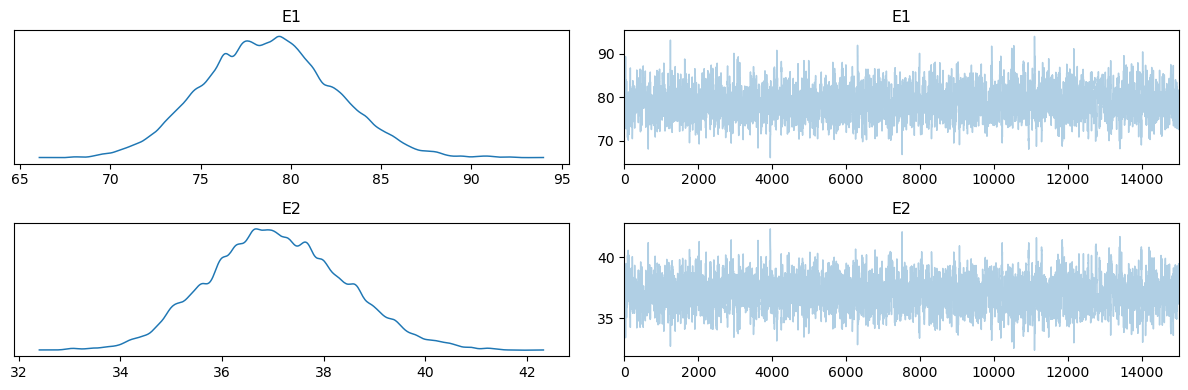

In [31]:
# restults
print(true_parameters)
az.plot_trace(idata1)
plt.tight_layout()
plt.show()

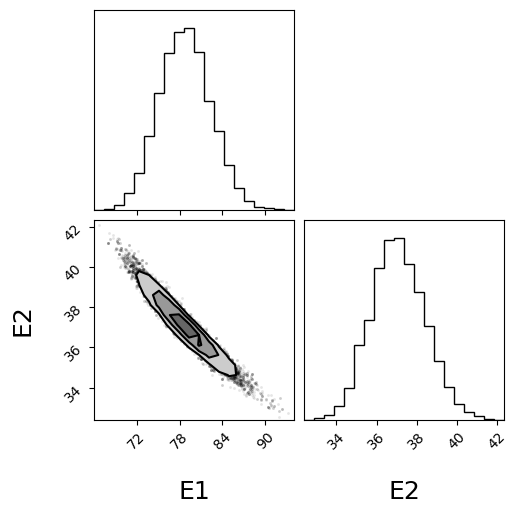

In [32]:
figure = corner.corner(idata1, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)


Average distance: 1.3144866016322987
Zero-distance pairs: 9508


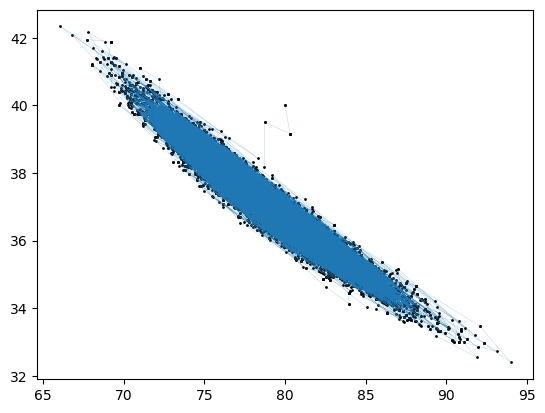

In [33]:
param = extract_parameters(my_chain_l1['chain_0'])
plt.scatter(param[:,0], param[:,1], s=1, c='k')
plt.plot(param[:,0], param[:,1], lw=0.1)


In [ ]:
my_chain_l2 = tda.sample(my_posterior_l2, my_proposal, iterations=20000, n_chains=1, initial_parameters=true_parameters) # 3 levels
idata2 = tda.to_inference_data(my_chain_l2, burnin=5000, parameter_names = ['E1', 'E2'])
az.summary(idata2)

Sampling chain 1/1


Running chain, α = 0.48:  66%|██████▋   | 13291/20000 [03:05<01:32, 72.50it/s]

[80 40]


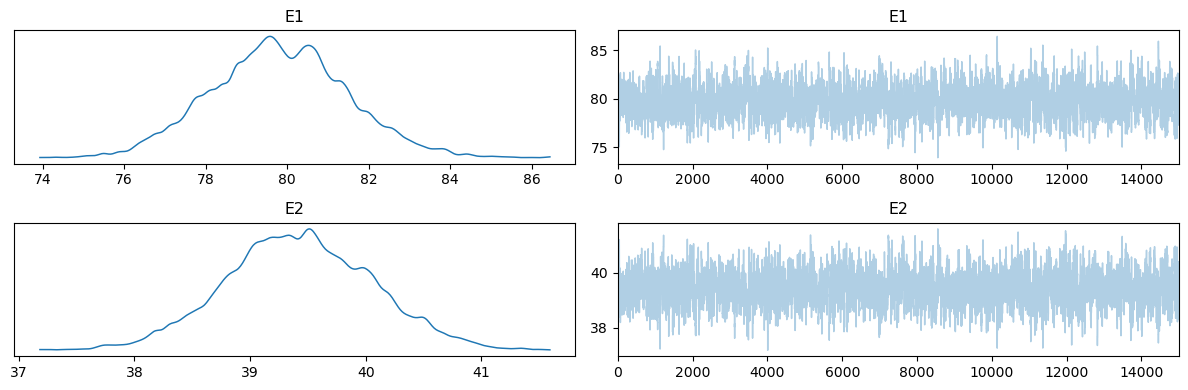

In [ ]:
print(true_parameters)
az.plot_trace(idata2)
plt.tight_layout()
plt.show()

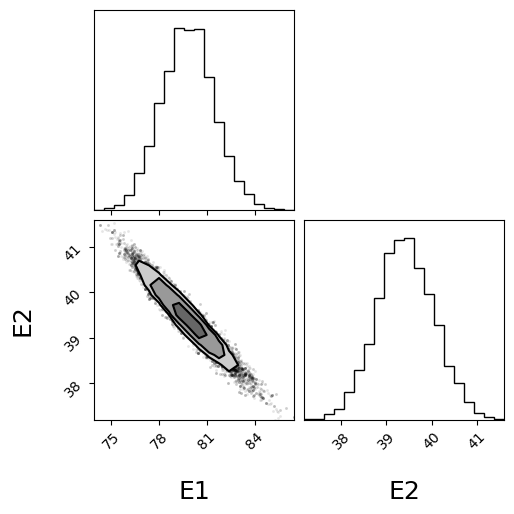

In [ ]:
figure = corner.corner(idata2, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)


In [ ]:
#higher resolution model

my_chain_l3 = tda.sample(my_posterior_l3, my_proposal, iterations=20000, n_chains=1, initial_parameters=true_parameters) # 3 levels
idata3 = tda.to_inference_data(my_chain_l3, burnin=5000, parameter_names = ['E1', 'E2'])
az.summary(idata3)

Sampling chain 1/1


Running chain, α = 0.47: 100%|██████████| 20000/20000 [27:31<00:00, 12.11it/s]
/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 15001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,80.293,1.701,76.972,83.331,0.047,0.033,1334.0,1940.0,NaN
E2,39.647,0.651,38.389,40.851,0.018,0.013,1297.0,1887.0,NaN


[80 40]


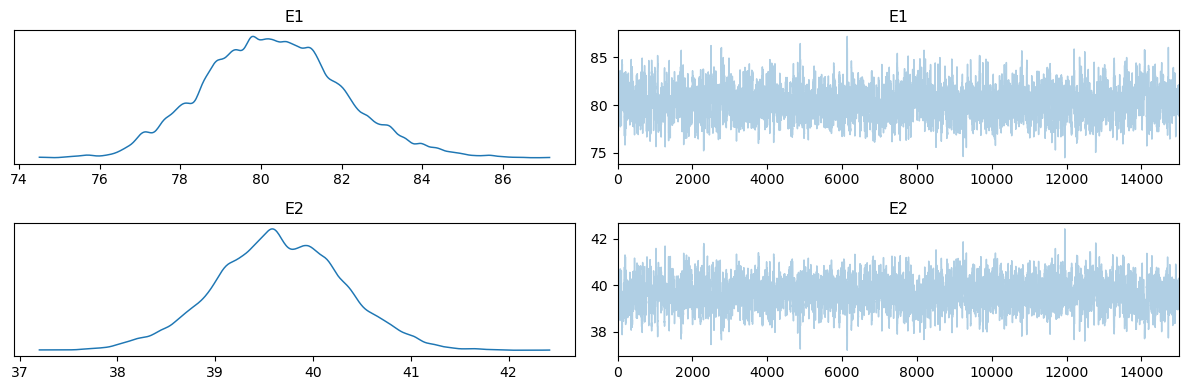

In [ ]:
print(true_parameters)
az.plot_trace(idata3)
plt.tight_layout()
plt.show()

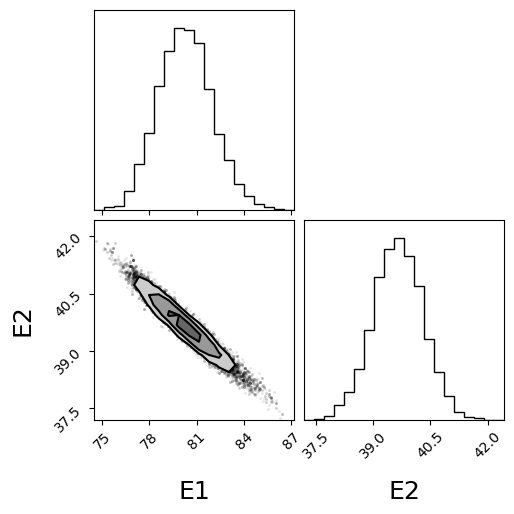

In [ ]:
figure = corner.corner(idata3, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)


Average distance: 0.5883106759333446
Zero-distance pairs: 9960
Average distance: 0.6351753099252487
Zero-distance pairs: 8888
Average distance: 0.6419442814907369
Zero-distance pairs: 8891


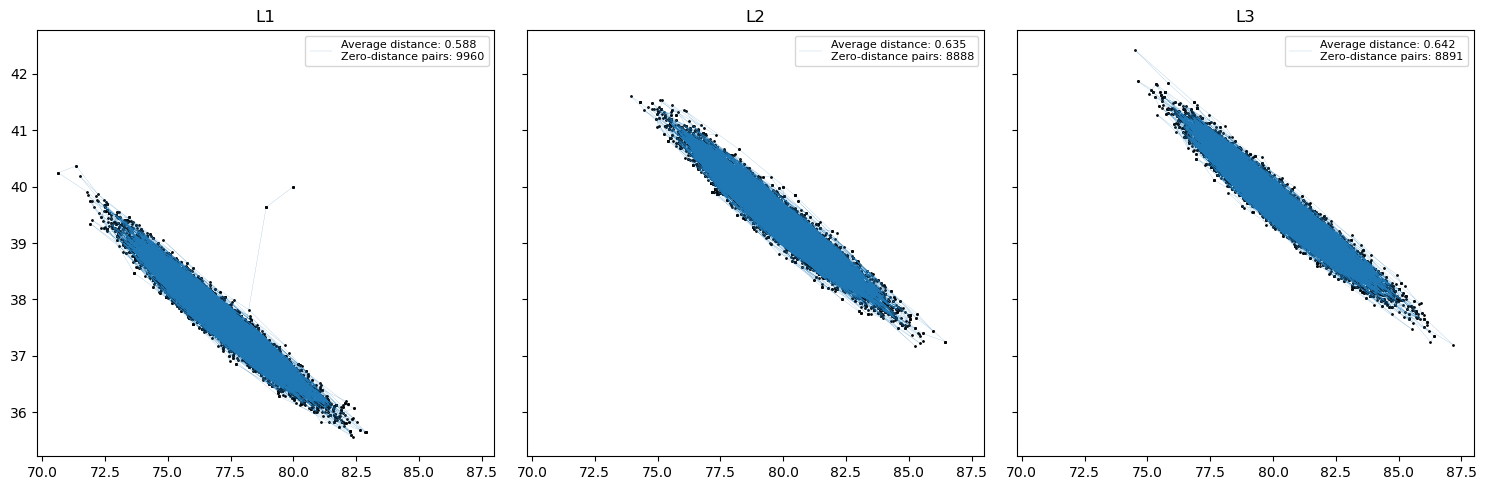

In [ ]:
chains = {
    'L1': my_chain_l1,
    'L2': my_chain_l2,
    'L3': my_chain_l3,
}


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (label, chain) in zip(axes, chains.items()):
    param = extract_parameters(chain['chain_0'])

    # distances between consecutive points
    diffs = np.diff(param, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    avg_distance = distances.mean()
    zero_count = np.sum(distances == 0)

    ax.scatter(param[:, 0], param[:, 1], s=1, c='k')
    ax.plot(
        param[:, 0], param[:, 1], lw=0.1,
        label=f"Average distance: {avg_distance:.3g}\nZero-distance pairs: {zero_count}"
    )
    ax.set_title(label)
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_levels.png')
plt.show()


# Multilevel Experiments

In [ ]:
my_chain_ml = tda.sample([my_posterior_l1, my_posterior_l3], my_proposal, iterations=3500, n_chains=1, initial_parameters=MAP, subchain_length=10, adaptive_error_model='state-independent') # 2 levels
idata4 = tda.to_inference_data(my_chain_ml, level='fine', burnin=500, parameter_names = ['E1', 'E2'])
az.summary(idata4)

Sampling chain 1/1


Running chain, α_c = 1.000, α_f = 1.00:   0%|          | 0/3500 [00:00<?, ?it/s]/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/tinyDA/proposal.py:258: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α_c = 0.833, α_f = 1.00:   0%|          | 1/3500 [00:00<06:03,  9.62it/s]/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/tinyDA/chain.py:477: RuntimeWarning: overflow encountered in exp
  alpha_2 = np.exp(
Running chain, α_c = 0.475, α_f = 0.87: 100%|██████████| 3500/3500 [07:03<00:00,  8.27it/s]
/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 3001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,80.275,1.711,77.018,83.356,0.044,0.031,1517.0,1732.0,NaN
E2,39.652,0.645,38.379,40.802,0.016,0.012,1562.0,1798.0,NaN


[80 40]


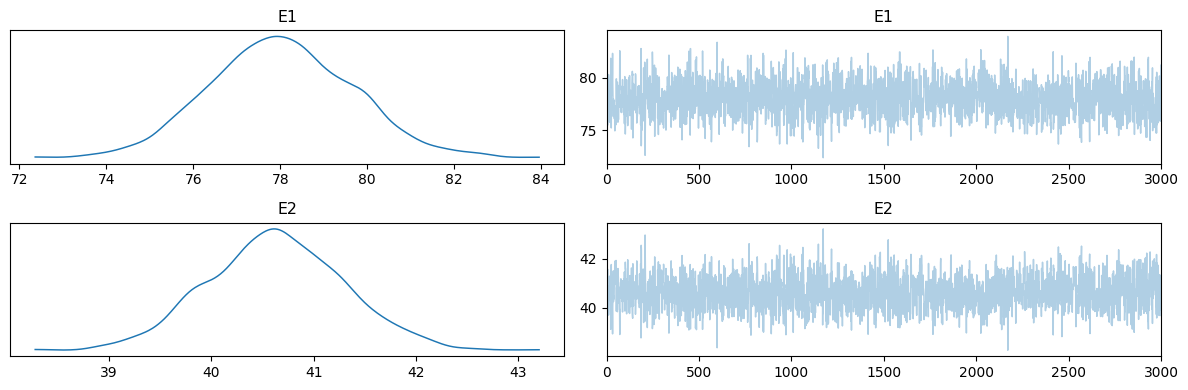

In [ ]:
print(true_parameters)
az.plot_trace(idata4)
plt.tight_layout()
plt.show()

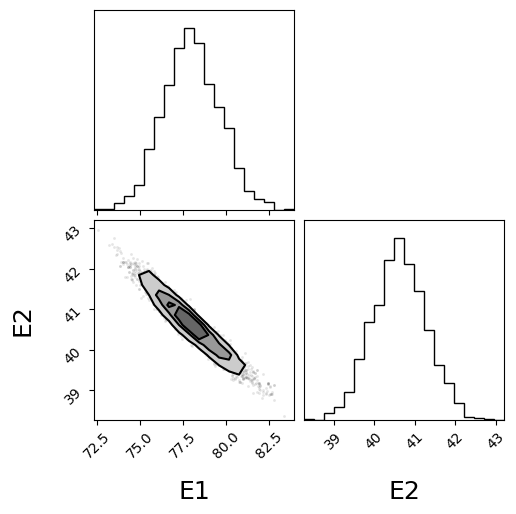

In [ ]:
figure = corner.corner(idata4, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)

In [ ]:
my_chain_m3l = tda.sample([my_posterior_l1, my_posterior_l2, my_posterior_l3], my_proposal, iterations=2500, n_chains=1, initial_parameters=MAP, subchain_length=[5,5], adaptive_error_model='state-independent') # 2 levels
idata5 = tda.to_inference_data(my_chain_m3l, level='2', burnin=500, parameter_names = ['E1', 'E2'])
az.summary(idata5)

Sampling chain 1/1


Running chain, α = 1.00: 100%|██████████| 2500/2500 [09:41<00:00,  4.30it/s]
/Users/louisekluge/lin_el/.pixi/envs/default/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 2001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,77.899,1.589,75.087,81.082,0.037,0.026,1871.0,1848.0,NaN
E2,40.662,0.648,39.488,41.888,0.015,0.011,1882.0,1922.0,NaN


[80 40]


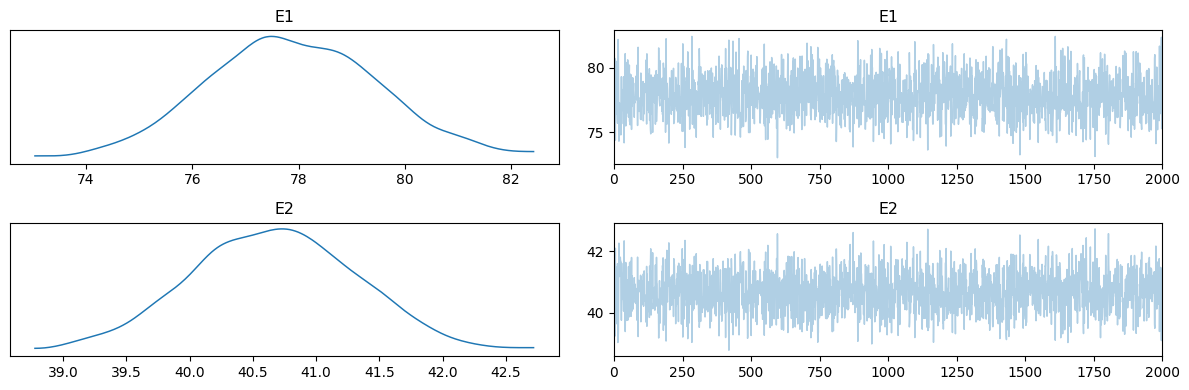

In [ ]:
print(true_parameters)
az.plot_trace(idata5)
plt.tight_layout()
plt.show()

# Full Inversion

In [28]:
def eval_ll1(gridpts):
    eval = []
    for index in range(len(gridpts)):
        eval.append(my_loglike_1.loglike(model1(gridpts[index,:])[0]))
    return np.array(eval)

def eval_ll2(gridpts):
    eval = []
    for index in range(len(gridpts)):
        eval.append(my_loglike_2.loglike(model2(gridpts[index,:])[0]))
    return np.array(eval)

def eval_ll3(gridpts):
    eval = []
    for index in range(len(gridpts)):
        eval.append(my_loglike_3.loglike(model3(gridpts[index,:])[0]))
    return np.array(eval)

## Single Distribution

In [ ]:
t1_vals = np.linspace(70, 85, 100)
t2_vals = np.linspace(38, 45, 100)
T1, T2  = np.meshgrid(t1_vals, t2_vals)
# Stack T1, T2 into an (N*N, 2) array of grid points
gridpts = np.column_stack([T1.ravel(), T2.ravel()])

# Evaluate — returns shape (N*N,)
Z_flat = eval_ll2(gridpts)


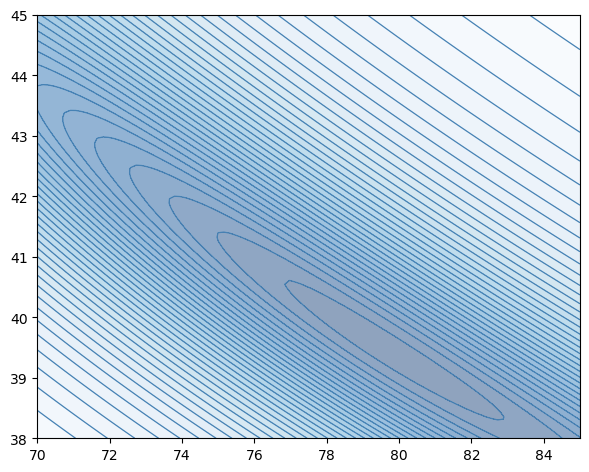

In [ ]:
Z = -Z_flat.reshape(T1.shape)
fig, ax = plt.subplots(figsize=(7, 5.5))

cf = ax.contourf(T1, T2, 1/Z, levels=40, cmap="Blues", alpha=0.45)

cs = ax.contour(T1, T2, 1/Z, levels=40, colors="steelblue", linewidths=0.9);

KeyboardInterrupt: 

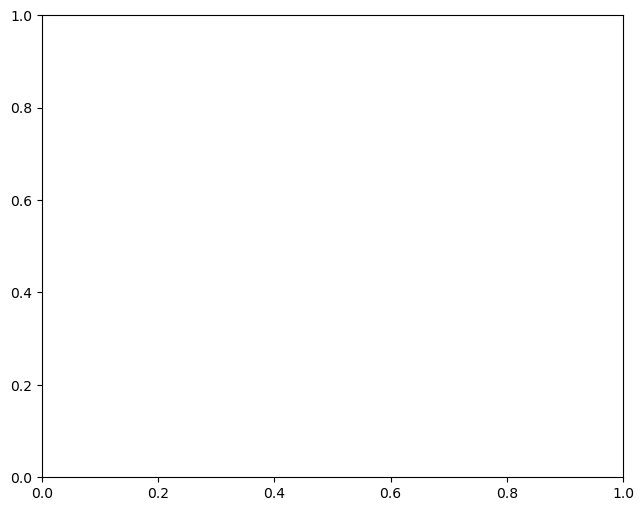

: 

In [ ]:
def eval_loglike(model, loglike, gridpts):
    return np.array([loglike.loglike(model(theta)[0]) for theta in gridpts])

# grid (consider 60x60 while iterating: 3 models x N^2 solves adds up)
t1_vals = np.linspace(72, 84, 100)
t2_vals = np.linspace(36, 42, 100)
T1, T2 = np.meshgrid(t1_vals, t2_vals)
gridpts = np.column_stack([T1.ravel(), T2.ravel()])

surfaces = {
    "L1": (model1, my_loglike_1, "Blues",   "steelblue"),
    "L2": (model2, my_loglike_2, "Oranges", "darkorange"),
    "L3": (model3, my_loglike_3, "Greens",  "seagreen"),
}

fig, ax = plt.subplots(figsize=(7.5, 6))
levels = np.linspace(0.05, 1, 9)   # contours of normalized likelihood
handles = []

for label, (model, loglike, cmap, line_color) in surfaces.items():
    ll = eval_loglike(model, loglike, gridpts)
    L = np.exp(ll - ll.max()).reshape(T1.shape)   # normalized likelihood in [0, 1]

    ax.contourf(T1, T2, L, levels=levels, cmap=cmap, alpha=0.40)
    #ax.contour(T1, T2, L, levels=levels, colors=line_color, linewidths=0.9, alpha=0.9)
    handles.append(plt.Line2D([], [], color=line_color, lw=2, label=label))

ax.plot(*true_parameters, "k*", ms=12, label="truth")
handles.append(plt.Line2D([], [], color="k", marker="*", ls="", ms=10, label="truth"))

ax.set_xlabel(r"$E_1$")
ax.set_ylabel(r"$E_2$")
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.show()

## Comparison plot

In [19]:
def eval_loglike(model, loglike, gridpts):
    return np.array([loglike.loglike(model(theta)[0]) for theta in gridpts])

# grid (consider 60x60 while iterating: 3 models x N^2 solves adds up)
t1_vals = np.linspace(72, 84, 100)
t2_vals = np.linspace(36, 42, 100)
T1, T2 = np.meshgrid(t1_vals, t2_vals)
gridpts = np.column_stack([T1.ravel(), T2.ravel()])

levels_to_eval = {
    "L1": (model1, my_loglike_1),
    "L2": (model2, my_loglike_2),
    "L3": (model3, my_loglike_3),
}

# raw log-likelihood per level, reshaped to the grid
ll_grid = {
    label: eval_loglike(model, loglike, gridpts).reshape(T1.shape)
    for label, (model, loglike) in levels_to_eval.items()
}

# optional: save so a kernel restart doesn't cost you the solves
np.savez("ll_grid.npz", T1=T1, T2=T2, **ll_grid)

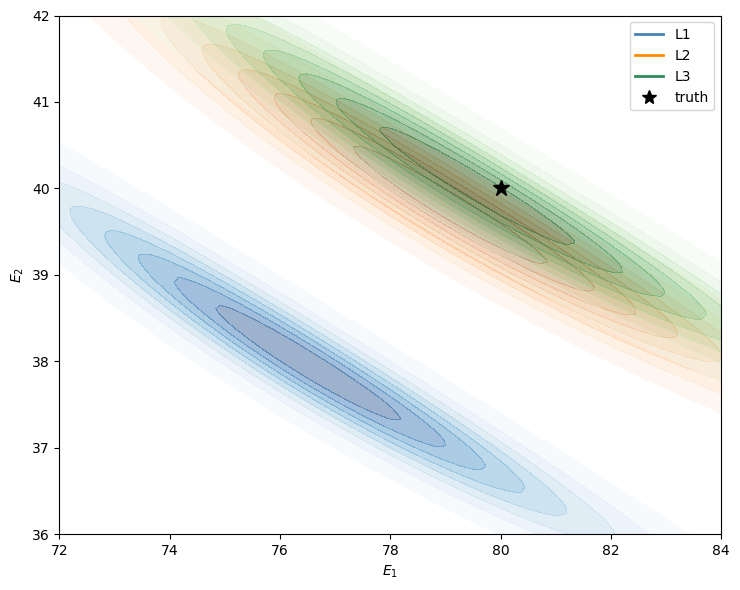

In [20]:
# to reload after a restart: (computation with fixed random seed "678")
d = np.load("ll_grid.npz"); T1, T2 = d["T1"], d["T2"]
ll_grid = {k: d[k] for k in ("L1", "L2", "L3")}

styles = {
    "L1": ("Blues",   "steelblue"),
    "L2": ("Oranges", "darkorange"),
    "L3": ("Greens",  "seagreen"),
}

fig, ax = plt.subplots(figsize=(7.5, 6))
levels = np.linspace(0.05, 1, 9)   # contours of normalized likelihood
handles = []

for label, ll in ll_grid.items():
    cmap, line_color = styles[label]
    L = np.exp(ll - ll.max())      # normalized likelihood in [0, 1]

    ax.contourf(T1, T2, L, levels=levels, cmap=cmap, alpha=0.40, extend="max")
    #ax.contour(T1, T2, L, levels=levels, colors=line_color, linewidths=0.9, alpha=0.9)
    handles.append(plt.Line2D([], [], color=line_color, lw=2, label=label))

ax.plot(*true_parameters, "k*", ms=12)
handles.append(plt.Line2D([], [], color="k", marker="*", ls="", ms=10, label="truth"))

ax.set_xlabel(r"$E_1$")
ax.set_ylabel(r"$E_2$")
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.show()

# GP Training

### Subspace for training

In [21]:
from scipy.stats import qmc

# parameter subcube for training (adjust to your region of interest)
lhs_lo, lhs_hi = np.array([70., 35.]), np.array([90., 45.])
n_train = 200

theta_train = qmc.scale(qmc.LatinHypercube(d=2, seed=0).random(n_train), lhs_lo, lhs_hi)

Y_out = np.array([model2(t)[0] for t in theta_train])              # (n_train, n_obs)
y_ll  = np.array([my_loglike_2.loglike(y) for y in Y_out])         # (n_train,)

In [22]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

def krige(X, y):
    kernel = C(1.0, (1e-3, 1e6)) * Matern(length_scale=(lhs_hi - lhs_lo) / 10, nu=2.5)
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                    n_restarts_optimizer=3, alpha=1e-10).fit(X, y)

gp_loglike = krige(theta_train, y_ll)     # 1. surrogate of the log-likelihood
gp_output  = krige(theta_train, Y_out)    # 2. surrogate of the model output (multi-output)

In [23]:
class GPModel:
    def __init__(self, gp): self.gp = gp
    def __call__(self, theta):
        return np.atleast_1d(self.gp.predict(np.atleast_2d(theta))[0]), 0

class IdentityLogLike:  # model "output" already IS the loglike
    def loglike(self, x): return float(np.ravel(x)[0])

model_gp_output_small = GPModel(gp_output)
model_gp_ll_small     = GPModel(gp_loglike)

post_gp_output_small = tda.Posterior(my_prior, tda.GaussianLogLike(data, cov_likelihood), model_gp_output_small)
post_gp_ll_small     = tda.Posterior(my_prior, IdentityLogLike(), model_gp_ll_small)

In [34]:
my_chain_gp_ll_small = tda.sample(post_gp_ll_small, my_proposal, iterations=20000, n_chains=1, initial_parameters=true_parameters) # 3 levels
idata_gp_lls = tda.to_inference_data(my_chain_gp_ll_small, burnin=5000, parameter_names = ['E1', 'E2'])
az.summary(idata_gp_lls)

Sampling chain 1/1


Running chain, α = 0.56: 100%|██████████| 20000/20000 [00:38<00:00, 519.22it/s]
/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 15001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,78.777,1.631,75.690,81.787,0.043,0.031,1429.0,1615.0,NaN
E2,40.144,0.645,38.954,41.394,0.017,0.012,1411.0,1677.0,NaN


[80 40]


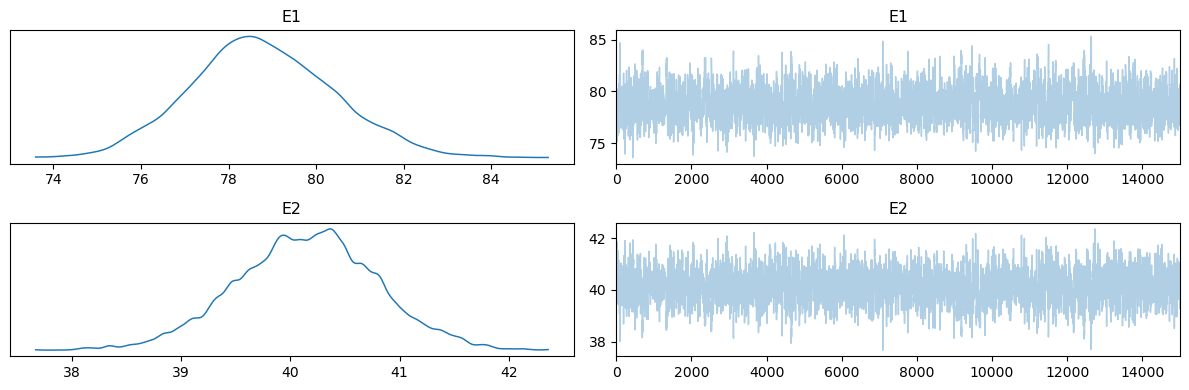

In [35]:
print(true_parameters)
az.plot_trace(idata_gp_lls)
plt.tight_layout()
plt.show()

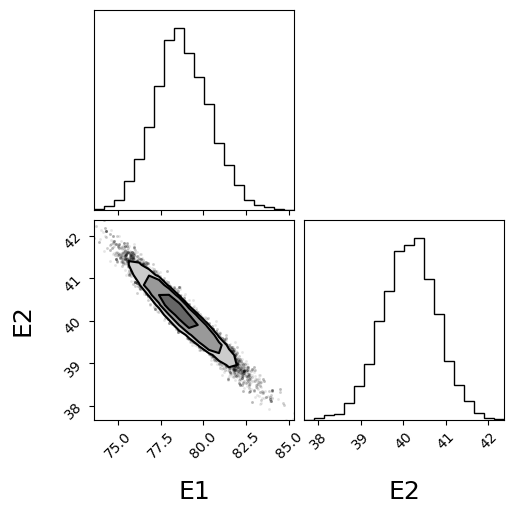

In [38]:
figure = corner.corner(idata_gp_lls, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)

In [43]:
my_chain_o_small = tda.sample(post_gp_output_small, my_proposal, iterations=20000, n_chains=1, initial_parameters=true_parameters) # 3 levels
idata_gp_os = tda.to_inference_data(my_chain_o_small, burnin=5000, parameter_names = ['E1', 'E2'])
az.summary(idata_gp_os)

Sampling chain 1/1


Running chain, α = 0.54: 100%|██████████| 20000/20000 [00:37<00:00, 530.12it/s]
/home/louisekluge/lin_el/.pixi/envs/default/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 15001), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
E1,78.869,1.641,75.921,81.975,0.044,0.031,1404.0,2071.0,NaN
E2,40.099,0.647,38.869,41.293,0.017,0.012,1411.0,1940.0,NaN


[80 40]


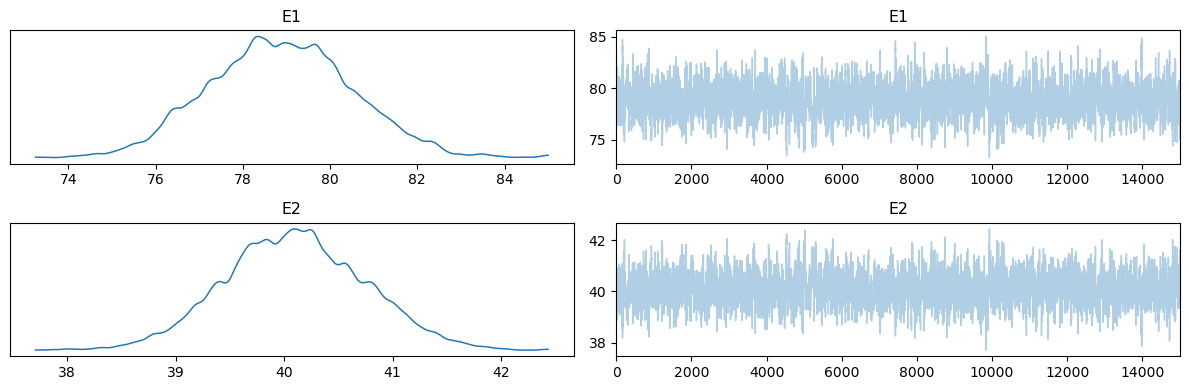

In [44]:
print(true_parameters)
az.plot_trace(idata_gp_os)
plt.tight_layout()
plt.show()

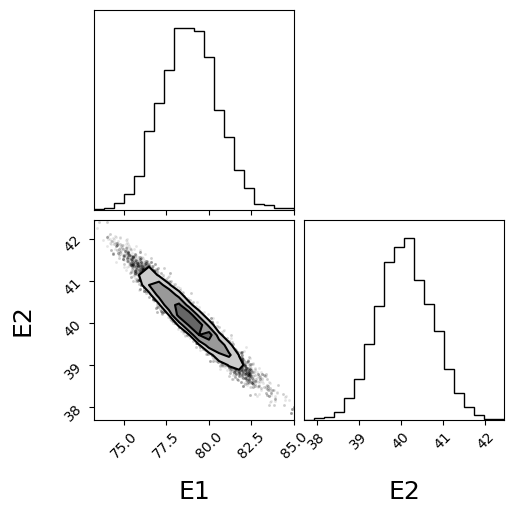

In [45]:
figure = corner.corner(idata_gp_os, fill_contours=True, plot_datapoints=True, label_kwargs={"fontsize": 18, "color": "black"},)

In [ ]:
def eval_loglike(model, loglike, gridpts):
    return np.array([loglike.loglike(model(theta)[0]) for theta in gridpts])

# grid (consider 60x60 while iterating: 3 models x N^2 solves adds up)
t1_vals = np.linspace(72, 84, 100)
t2_vals = np.linspace(36, 42, 100)
T1, T2 = np.meshgrid(t1_vals, t2_vals)
gridpts = np.column_stack([T1.ravel(), T2.ravel()])

surfaces = {
    "L1": (model1, my_loglike_1, "Blues",   "steelblue"),
    "L2": (model2, my_loglike_2, "Oranges", "darkorange"),
    "L3": (model3, my_loglike_3, "Greens",  "seagreen"),
}

fig, ax = plt.subplots(figsize=(7.5, 6))
levels = np.linspace(0.05, 0.95, 8)   # contours of normalized likelihood
handles = []

for label, (model, loglike, cmap, line_color) in surfaces.items():
    ll = eval_loglike(model, loglike, gridpts)
    L = np.exp(ll - ll.max()).reshape(T1.shape)   # normalized likelihood in [0, 1]

    ax.contourf(T1, T2, L, levels=levels, cmap=cmap, alpha=0.60)
    #ax.contour(T1, T2, L, levels=levels, colors=line_color, linewidths=0.9, alpha=0.9)
    handles.append(plt.Line2D([], [], color=line_color, lw=2, label=label))

ax.plot(*true_parameters, "k*", ms=12, label="truth")
handles.append(plt.Line2D([], [], color="k", marker="*", ls="", ms=10, label="truth"))

ax.set_xlabel(r"$E_1$")
ax.set_ylabel(r"$E_2$")
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.show()